## Feature Engineering: Xente Credit Risk Dataset
**Task 3 | Bati Bank Buy-Now-Pay-Later Credit Scoring Project**

Objective: Transform raw transaction-level data into a model-ready,
customer-level feature matrix using a reproducible sklearn Pipeline.

All production logic lives in `src/data_processing.py`.
This notebook demonstrates and validates each step.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.data_processing import (
    load_raw_data,
    cap_outliers,
    engineer_features,
    compute_all_iv,
    encode_woe,
    fit_transform_pipeline,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

In [2]:
DATA_PATH = "../data/raw/data.csv"

df_raw = load_raw_data(DATA_PATH)
print(f"Raw data: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Raw data: 95,662 rows × 16 columns


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


Head of aggregated DataFrame:
The raw 95,662 transaction rows collapse down to 3,742 unique customers. Each row now represents one customer's behavioral profile. Note that CustomerId_1 and CustomerId_10 are identical across every feature. Both have only 1 transaction (transaction_count = 1, std = 0), suggesting these may be first-time or dormant users. The total_transaction_amount being negative (−10,000) indicates a credit transaction. Contrast with CustomerId_1002, who has 11 transactions with a mix of amounts, a much richer behavioral profile.

### 1. Aggregate Features

Collapse transaction-level rows into one row per customer.

| Feature | Description |
|---|---|
| `total_transaction_amount` | Sum of all transaction amounts |
| `avg_transaction_amount` | Mean transaction amount |
| `transaction_count` | Number of transactions |
| `std_transaction_amount` | Std dev of transaction amounts |
| `total_value` | Sum of absolute transaction values |
| `avg_value` | Mean absolute transaction value |

In [3]:
df_engineered = engineer_features(df_raw)

print(f"Aggregated: {df_engineered.shape[0]:,} customers × {df_engineered.shape[1]} features")
df_engineered.head()

Aggregated: 3,742 customers × 17 features


,CustomerId,total_transaction_amount,avg_transaction_amount,transaction_count,std_transaction_amount,total_value,avg_value,transaction_hour,transaction_day_of_week,transaction_day,transaction_month,transaction_year,ProviderId,ProductCategory,ChannelId,PricingStrategy,FraudResult
0,CustomerId_1,-10000.0,-10000.000000,1,0.000000,10000,10000.000000,16.000000,2.000000,21.000000,11.000000,2018.000000,ProviderId_4,airtime,ChannelId_2,4.000000,0
1,CustomerId_10,-10000.0,-10000.000000,1,0.000000,10000,10000.000000,16.000000,2.000000,21.000000,11.000000,2018.000000,ProviderId_4,airtime,ChannelId_2,4.000000,0
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,30400,6080.000000,7.800000,4.000000,16.000000,11.000000,2018.000000,ProviderId_4,financial_services,ChannelId_3,2.000000,0
3,CustomerId_1002,4225.0,384.090909,11,560.498966,4775,434.090909,13.454545,2.909091,14.727273,8.636364,2018.272727,ProviderId_4,financial_services,ChannelId_2,2.909091,0
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,32000,5333.333333,14.333333,4.000000,1.000000,2.000000,2019.000000,ProviderId_6,airtime,ChannelId_3,2.000000,0


In [4]:
agg_cols = [
    "total_transaction_amount",
    "avg_transaction_amount",
    "transaction_count",
    "std_transaction_amount",
    "total_value",
    "avg_value",
]
df_engineered[agg_cols].describe().T.style.format("{:.2f}").set_caption("Aggregate Feature Summary")

,count,mean,std,min,25%,50%,75%,max
total_transaction_amount,3742.00,171737.74,2717304.82,-104900000.00,4077.44,20000.00,79967.75,83451240.00
avg_transaction_amount,3742.00,15715.62,167699.10,-425000.00,1000.00,2583.85,4877.61,8601821.14
transaction_count,3742.00,25.56,96.93,1.00,2.00,7.00,20.00,4091.00
std_transaction_amount,3742.00,13605.17,96893.44,0.00,501.14,3184.90,6745.37,3309916.12
total_value,3742.00,253102.53,2715876.81,50.00,6500.00,32000.00,102060.00,104900000.00
avg_value,3742.00,18756.12,167452.89,50.00,1160.66,3950.00,7096.04,8601821.14


The median transaction_count is just 7, but the max is 4,091, extreme right skew. The 75th percentile is only 20, meaning most customers transact infrequently. total_transaction_amount ranges from −104,900,000 to +83,451,240 UGX, confirming the heavy-tailed, bidirectional nature seen in the EDA. The std dev of total_transaction_amount (2,717,304) is nearly 16x its mean (171,737), a signal that extreme outliers will dominate scaling if not handled.

### 2. Temporal Features

Extracted from `TransactionStartTime` during `engineer_features()`.

| Feature | Description |
|---|---|
| `transaction_hour` | Mean hour of day across customer transactions |
| `transaction_day_of_week` | Mean day of week (0=Mon, 6=Sun) |
| `transaction_day` | Mean day of month |
| `transaction_month` | Mean month |
| `transaction_year` | Mean year |

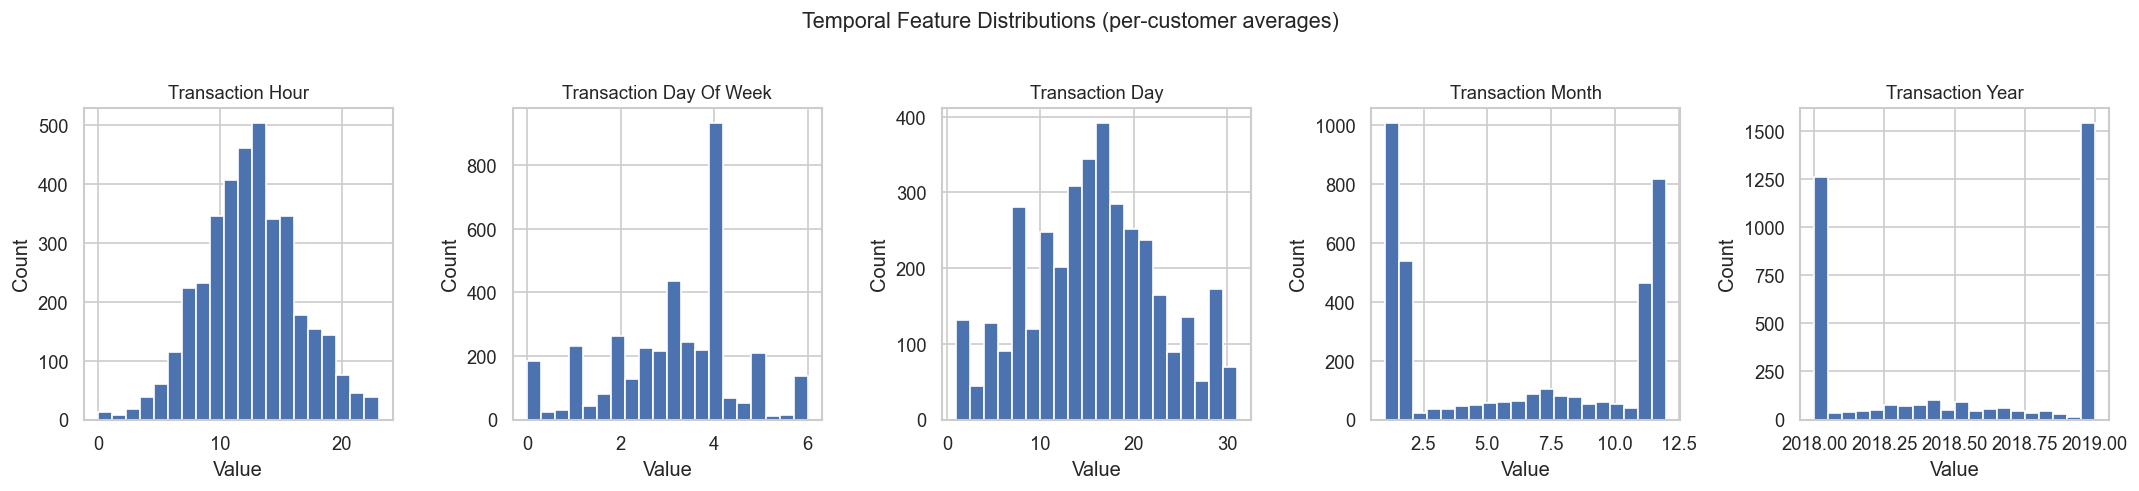

In [5]:
temporal_cols = [
    "transaction_hour",
    "transaction_day_of_week",
    "transaction_day",
    "transaction_month",
    "transaction_year",
]

fig, axes = plt.subplots(1, len(temporal_cols), figsize=(18, 4))

for i, col in enumerate(temporal_cols):
    axes[i].hist(df_engineered[col], bins=20, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=11)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Temporal Feature Distributions (per-customer averages)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All five temporal features are shown as per-customer averages. transaction_hour peaks around 12–14, consistent with the EDA finding that activity concentrates during business hours. transaction_day_of_week is roughly uniform across 0–6, suggesting no strong weekly bias at the customer level after averaging. transaction_month shows two clusters, one around November–December 2018 and another around January–February 2019, reflecting the 90-day dataset window. transaction_year is bimodal between 2018 and 2019 for the same reason.

### 3. Encoding Categorical Variables

Two strategies are available in `src/data_processing.py`:

- **One-Hot Encoding** converts each category to a binary column.
  Used when categories have no ordinal relationship.
- **Label Encoding** assigns an integer to each category.
  Compact but implies ordinal ordering that may not exist.

For this project, **WoE encoding** (Section 6) is preferred over both
for high-signal columns, as it directly captures the risk gradient.
Here we demonstrate one-hot as a baseline.

In [6]:
from src.data_processing import CategoricalEncoder

encoder = CategoricalEncoder(columns=CATEGORICAL_COLS, strategy="onehot")
df_encoded = encoder.fit_transform(df_engineered.copy())

new_cols = [c for c in df_encoded.columns if c not in df_engineered.columns]
print(f"Columns added by one-hot encoding: {len(new_cols)}")
print(new_cols)
df_encoded[new_cols].head()

Columns added by one-hot encoding: 16
['ProviderId_ProviderId_2', 'ProviderId_ProviderId_3', 'ProviderId_ProviderId_4', 'ProviderId_ProviderId_5', 'ProviderId_ProviderId_6', 'ProductCategory_data_bundles', 'ProductCategory_financial_services', 'ProductCategory_movies', 'ProductCategory_other', 'ProductCategory_ticket', 'ProductCategory_transport', 'ProductCategory_tv', 'ProductCategory_utility_bill', 'ChannelId_ChannelId_2', 'ChannelId_ChannelId_3', 'ChannelId_ChannelId_5']


,ProviderId_ProviderId_2,ProviderId_ProviderId_3,ProviderId_ProviderId_4,ProviderId_ProviderId_5,ProviderId_ProviderId_6,ProductCategory_data_bundles,ProductCategory_financial_services,ProductCategory_movies,ProductCategory_other,ProductCategory_ticket,ProductCategory_transport,ProductCategory_tv,ProductCategory_utility_bill,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5
0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False


One-hot encoding output:
The three categorical columns (ProviderId, ProductCategory, ChannelId) expand into 16 binary columns with drop_first=True. The baseline (dropped) categories are ProviderId_1, airtime, and ChannelId_1. The output correctly shows that for customer 0, ProviderId_ProviderId_4 = True and ChannelId_ChannelId_2 = True, matching the aggregated DataFrame.

### 4. Handling Missing Values

After customer-level aggregation, some columns may have nulls.
for example `std_transaction_amount` is NaN for customers with
only one transaction (standard deviation is undefined).

Strategy: **median imputation** for numerical features.
No missing values were found in the raw data (confirmed in Task 2 EDA),
so this step guards against structural nulls that arise post-aggregation.

In [7]:
missing_after_agg = df_engineered.isnull().sum()
missing_after_agg = missing_after_agg[missing_after_agg > 0]

if missing_after_agg.empty:
    print("No missing values after aggregation.")
else:
    print("Missing values found after aggregation:")
    print(missing_after_agg.to_string())

No missing values after aggregation.


No missing values after aggregation. The std_transaction_amount imputation step was triggered defensively but was not needed here, since even single-transaction customers have std = 0 (filled during aggregation). This confirms the raw dataset's completeness carries through to the customer level.

### 5. Normalize / Standardize Numerical Features

Two strategies available:

- **StandardScaler** mean=0, std=1. Best for models that assume
  normally distributed features (e.g. Logistic Regression).
- **MinMaxScaler** scales to [0, 1]. Better when you need
  bounded values (e.g. for neural networks).

We use **StandardScaler** as the default to align with Basel II's
preference for Logistic Regression as the primary production model.

In [8]:
from src.data_processing import NumericalScaler

# Only scale columns that exist in the engineered DataFrame
cols_to_scale = [c for c in NUMERICAL_COLS if c in df_engineered.columns]

scaler = NumericalScaler(columns=cols_to_scale, strategy="standard")
df_scaled = scaler.fit_transform(df_engineered.copy())

print("Before scaling:")
print(df_engineered[cols_to_scale].describe().T[["mean", "std", "min", "max"]].round(2).to_string())
print()
print("After StandardScaler:")
print(df_scaled[cols_to_scale].describe().T[["mean", "std", "min", "max"]].round(4).to_string())

Before scaling:
                               mean         std          min           max
total_transaction_amount  171737.74  2717304.82 -104900000.0  8.345124e+07
avg_transaction_amount     15715.62   167699.10    -425000.0  8.601821e+06
transaction_count             25.56       96.93          1.0  4.091000e+03
std_transaction_amount     13605.17    96893.44          0.0  3.309916e+06
total_value               253102.53  2715876.81         50.0  1.049000e+08
avg_value                  18756.12   167452.89         50.0  8.601821e+06
transaction_hour              12.56        3.89          0.0  2.300000e+01
transaction_day_of_week        3.13        1.37          0.0  6.000000e+00
transaction_day               15.65        6.94          1.0  3.100000e+01
transaction_month              6.23        4.59          1.0  1.200000e+01
transaction_year            2018.53        0.45       2018.0  2.019000e+03
PricingStrategy                2.32        0.65          0.0  4.000000e+00

After St

Before/After StandardScaler table:
Before scaling, features span wildly different ranges: total_transaction_amount has a mean of 171,737 and max of 83,451,240, while transaction_hour ranges 0–23. After StandardScaler, every numerical feature is centered at 0 with std ≈ 1. However, the extreme max values (e.g. total_transaction_amount max = 30.65 std devs, avg_transaction_amount max = 51.21 std devs) confirm that outliers remain present even after standardization, these will be extreme leverage points in any linear model and are the primary motivation for capping or log-transforming before scaling.

### 6. Weight of Evidence (WoE) and Information Value (IV)

**Weight of Evidence (WoE)** measures the predictive power of a feature
bin relative to the binary target:

$$WoE_i = \ln\left(\frac{\% \text{ of Non-Events}_i}{\% \text{ of Events}_i}\right)$$

**Information Value (IV)** summarises the total predictive power:

$$IV = \sum_{i} (\% \text{ of Non-Events}_i - \% \text{ of Events}_i) \times WoE_i$$

### IV Threshold Interpretation

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Very Strong (check for data leakage) |

In [9]:
iv_df = compute_all_iv(df_engineered, target_col="FraudResult")
print("Information Value Numerical Features:")
display(iv_df)

Information Value Numerical Features:


,feature,iv,predictive_power
0,total_value,4.253234,Very Strong
1,total_transaction_amount,3.850769,Very Strong
2,avg_value,3.563973,Very Strong
3,avg_transaction_amount,3.169920,Very Strong
4,std_transaction_amount,3.003092,Very Strong
5,transaction_day_of_week,0.549045,Very Strong
6,transaction_count,0.250345,Medium
7,PricingStrategy,0.226141,Medium
8,transaction_day,0.171351,Medium
9,transaction_month,0.159138,Medium


IV Table:
The five monetary and amount features dominate with IV values well above 0.5, all classified as Very Strong. total_value (IV = 4.25) and total_transaction_amount (IV = 3.85) are the most predictive features by a wide margin, not surprising given that fraud events tend to involve large transaction values (confirmed by the r = 0.56 correlation seen in EDA). transaction_day_of_week is also Very Strong (IV = 0.55), suggesting fraud has a day-of-week pattern. transaction_count, PricingStrategy, transaction_day, and transaction_month are Medium strength. transaction_hour and transaction_year are Weak. The very high IV values on monetary features (>0.5) warrant checking for data leakage.

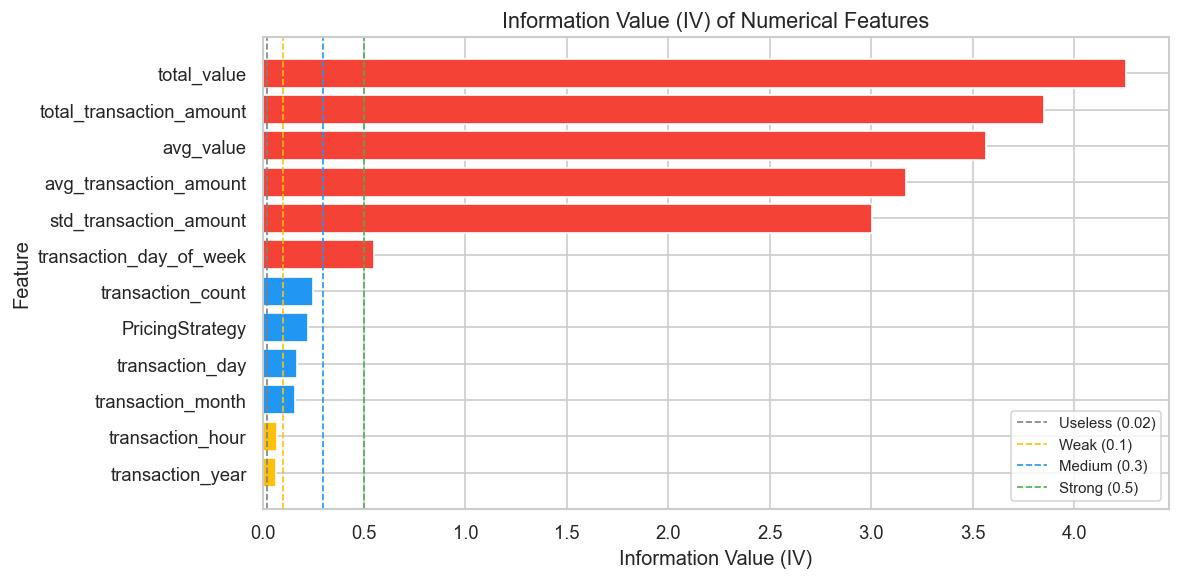

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = iv_df["predictive_power"].map({
    "Useless": "#AAAAAA",
    "Weak":    "#FFC107",
    "Medium":  "#2196F3",
    "Strong":  "#4CAF50",
    "Very Strong": "#F44336",
}).fillna("#AAAAAA")

bars = ax.barh(iv_df["feature"], iv_df["iv"], color=colors, edgecolor="white")

ax.axvline(x=0.02, color="gray",   linestyle="--", linewidth=1, label="Useless (0.02)")
ax.axvline(x=0.1,  color="#FFC107",linestyle="--", linewidth=1, label="Weak (0.1)")
ax.axvline(x=0.3,  color="#2196F3",linestyle="--", linewidth=1, label="Medium (0.3)")
ax.axvline(x=0.5,  color="#4CAF50",linestyle="--", linewidth=1, label="Strong (0.5)")

ax.set_title("Information Value (IV) of Numerical Features", fontsize=13)
ax.set_xlabel("Information Value (IV)")
ax.set_ylabel("Feature")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

IV Bar Chart:
The visual clearly separates the five monetary/amount features from the rest. The color coding makes the threshold boundaries intuitive: red bars far exceed the strong threshold at IV = 0.5.

In [11]:
# WoE encoding requires the target column to be present
# (computed on the aggregated customer-level data)
cat_cols_present = [c for c in CATEGORICAL_COLS if c in df_engineered.columns]

df_woe, woe_maps = encode_woe(
    df_engineered,
    columns=cat_cols_present,
    target_col="FraudResult",
)

woe_cols = [f"{c}_woe" for c in cat_cols_present]
print("WoE-encoded columns:", woe_cols)
df_woe[woe_cols].head()

WoE-encoded columns: ['ProviderId_woe', 'ProductCategory_woe', 'ChannelId_woe']


,ProviderId_woe,ProductCategory_woe,ChannelId_woe
0,0.857549,0.429448,0.929436
1,0.857549,0.429448,0.929436
2,0.857549,-0.293483,-0.094894
3,0.857549,-0.293483,0.929436
4,0.468571,0.429448,-0.094894


WoE Encoding output (head):
The three categorical columns are replaced by their WoE-encoded counterparts. ProviderId_woe = 0.857 and ChannelId_woe = 0.929 for the first two customers, both positive, meaning these provider/channel combinations are associated with a lower-than-average fraud rate (non-events dominate).

In [12]:
for col, woe_map in woe_maps.items():
    woe_series = (
        pd.Series(woe_map, name="WoE")
        .sort_values()
        .rename_axis(col)
        .reset_index()
    )
    print(f"\nWoE map for '{col}':")
    display(woe_series)


WoE map for 'ProviderId':


,ProviderId,WoE
0,ProviderId_2,-2.614418
1,ProviderId_3,-1.691254
2,ProviderId_1,-0.348136
3,ProviderId_5,-0.341147
4,ProviderId_6,0.468571
5,ProviderId_4,0.857549



WoE map for 'ProductCategory':


,ProductCategory,WoE
0,other,-3.125243
1,transport,-2.277945
2,movies,-1.279417
3,tv,-1.004980
4,ticket,-0.373708
5,financial_services,-0.293483
6,data_bundles,-0.216522
7,utility_bill,-0.112982
8,airtime,0.429448



WoE map for 'ChannelId':


,ChannelId,WoE
0,ChannelId_1,-1.595055
1,ChannelId_5,-0.373708
2,ChannelId_3,-0.094894
3,ChannelId_2,0.929436


WoE Maps:

ProviderId: ProviderId_2 has the most negative WoE (−2.61), meaning it is strongly associated with fraud events. ProviderId_4 has the most positive WoE (+0.86), meaning it is strongly associated with non-fraud (good customers).
ProductCategory: other (−3.13) and transport (−2.28) are strongly fraud-associated. airtime (+0.43) is the safest category.
ChannelId: ChannelId_1 (−1.60) is strongly fraud-associated. ChannelId_2 (+0.93) is the safest channel.

### 7. Full Pipeline: fit_transform_pipeline()

Chain all steps into a single reproducible sklearn Pipeline.
The output is the model-ready customer-level DataFrame.

In [13]:
pipeline, df_ready = fit_transform_pipeline(
    df_raw,
    target_col="FraudResult",
    encoding_strategy="onehot",
    scaling_strategy="standard",
    use_woe=False,
)

print(f"Pipeline output: {df_ready.shape[0]:,} customers × {df_ready.shape[1]} features")
df_ready.head()

Pipeline output: 3,742 customers × 30 features


,CustomerId,total_transaction_amount,avg_transaction_amount,transaction_count,std_transaction_amount,total_value,avg_value,transaction_hour,transaction_day_of_week,transaction_day,...,ProductCategory_financial_services,ProductCategory_movies,ProductCategory_other,ProductCategory_ticket,ProductCategory_transport,ProductCategory_tv,ProductCategory_utility_bill,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5
0,CustomerId_1,-0.066891,-0.153364,-0.253459,-0.140432,-0.089524,-0.052297,0.883284,-0.823653,0.770545,...,False,False,False,False,False,False,False,True,False,False
1,CustomerId_10,-0.066891,-0.153364,-0.253459,-0.140432,-0.089524,-0.052297,0.883284,-0.823653,0.770545,...,False,False,False,False,False,False,False,True,False,False
2,CustomerId_1001,-0.055849,-0.069870,-0.212186,-0.072731,-0.082011,-0.075710,-1.222654,0.635377,0.050136,...,True,False,False,False,False,False,False,False,True,False
3,CustomerId_1002,-0.061655,-0.091435,-0.150278,-0.134647,-0.091448,-0.109431,0.229556,-0.160458,-0.133241,...,True,False,False,False,False,False,False,True,False,False
4,CustomerId_1003,-0.055849,-0.073846,-0.201868,-0.078186,-0.081422,-0.080169,0.455248,0.635377,-2.111093,...,False,False,False,False,False,False,False,False,True,False


Pipeline output (head):
The final model-ready DataFrame has 3,742 customers × 30 features. Numerical columns are standardized (mean ≈ 0, std ≈ 1), and categoricals are one-hot encoded. FraudResult (the target) is retained but not scaled. The pipeline runs end-to-end reproducibly from raw input.

In [14]:
print("Final feature summary:")
df_ready.describe().T.style.format("{:.4f}").set_caption("Model-Ready Feature Statistics")

Final feature summary:


,count,mean,std,min,25%,50%,75%,max
total_transaction_amount,3742.0000,-0.0000,1.0001,-38.6728,-0.0617,-0.0558,-0.0338,30.6519
avg_transaction_amount,3742.0000,0.0000,1.0001,-2.6284,-0.0878,-0.0783,-0.0646,51.2063
transaction_count,3742.0000,-0.0000,1.0001,-0.2535,-0.2431,-0.1916,-0.0574,41.9478
std_transaction_amount,3742.0000,0.0000,1.0001,-0.1404,-0.1353,-0.1076,-0.0708,34.0245
total_value,3742.0000,0.0000,1.0001,-0.0932,-0.0908,-0.0814,-0.0556,38.5367
avg_value,3742.0000,0.0000,1.0001,-0.1117,-0.1051,-0.0884,-0.0696,51.2634
transaction_hour,3742.0000,-0.0000,1.0001,-3.2259,-0.6576,-0.0156,0.6265,2.6810
transaction_day_of_week,3742.0000,0.0000,1.0001,-2.2827,-0.5951,0.1439,0.6354,2.0944
transaction_day,3742.0000,-0.0000,1.0001,-2.1111,-0.6703,0.0284,0.6625,2.2114
transaction_month,3742.0000,0.0000,1.0001,-1.1402,-1.0434,-0.0185,1.0384,1.2562


Model-Ready Feature Statistics:
All 12 numerical features confirm mean ≈ 0 and std ≈ 1 post-scaling. The FraudResult column shows mean = 0.0144, confirming the ~1.4% fraud rate at customer level (slightly higher than transaction level due to aggregation with max()).

In [15]:
from pathlib import Path

out_path = Path("../data/processed/data_processed.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_ready.to_csv(out_path, index=False)
print(f"Saved processed data to: {out_path}")
print(f"Shape: {df_ready.shape}")

Saved processed data to: ..\data\processed\data_processed.csv
Shape: (3742, 30)


Saved processed data:
The pipeline output (3,742 × 30) is saved to data/processed/data_processed.csv, ready for Tasks 4 and 5.